## Gurobi

**Concepts:** [Exact optimization](../routers.md#exact-optimization) **Reference:** [MILP Solvers](../reference/solvers.md) **Network/Router API:** [🎯 MILPRouter](hi23_milp.ipynb)

Solving the MILP model with Gurobi — commercial, with an academic license available. The approach and the full solver roster are described in [Exact optimization](../routers.md#exact-optimization), the model options in [Model options](../routers.md#model-options), and the installation steps in [Install](../install.md).

In [1]:
from optiwindnet.heuristics import constructor
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import G_from_S
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.svg import svgplot

### Initialize Gwynt y Mor

In [2]:
locations = load_repository()

In [3]:
L = locations.gwynt
capacity = 6

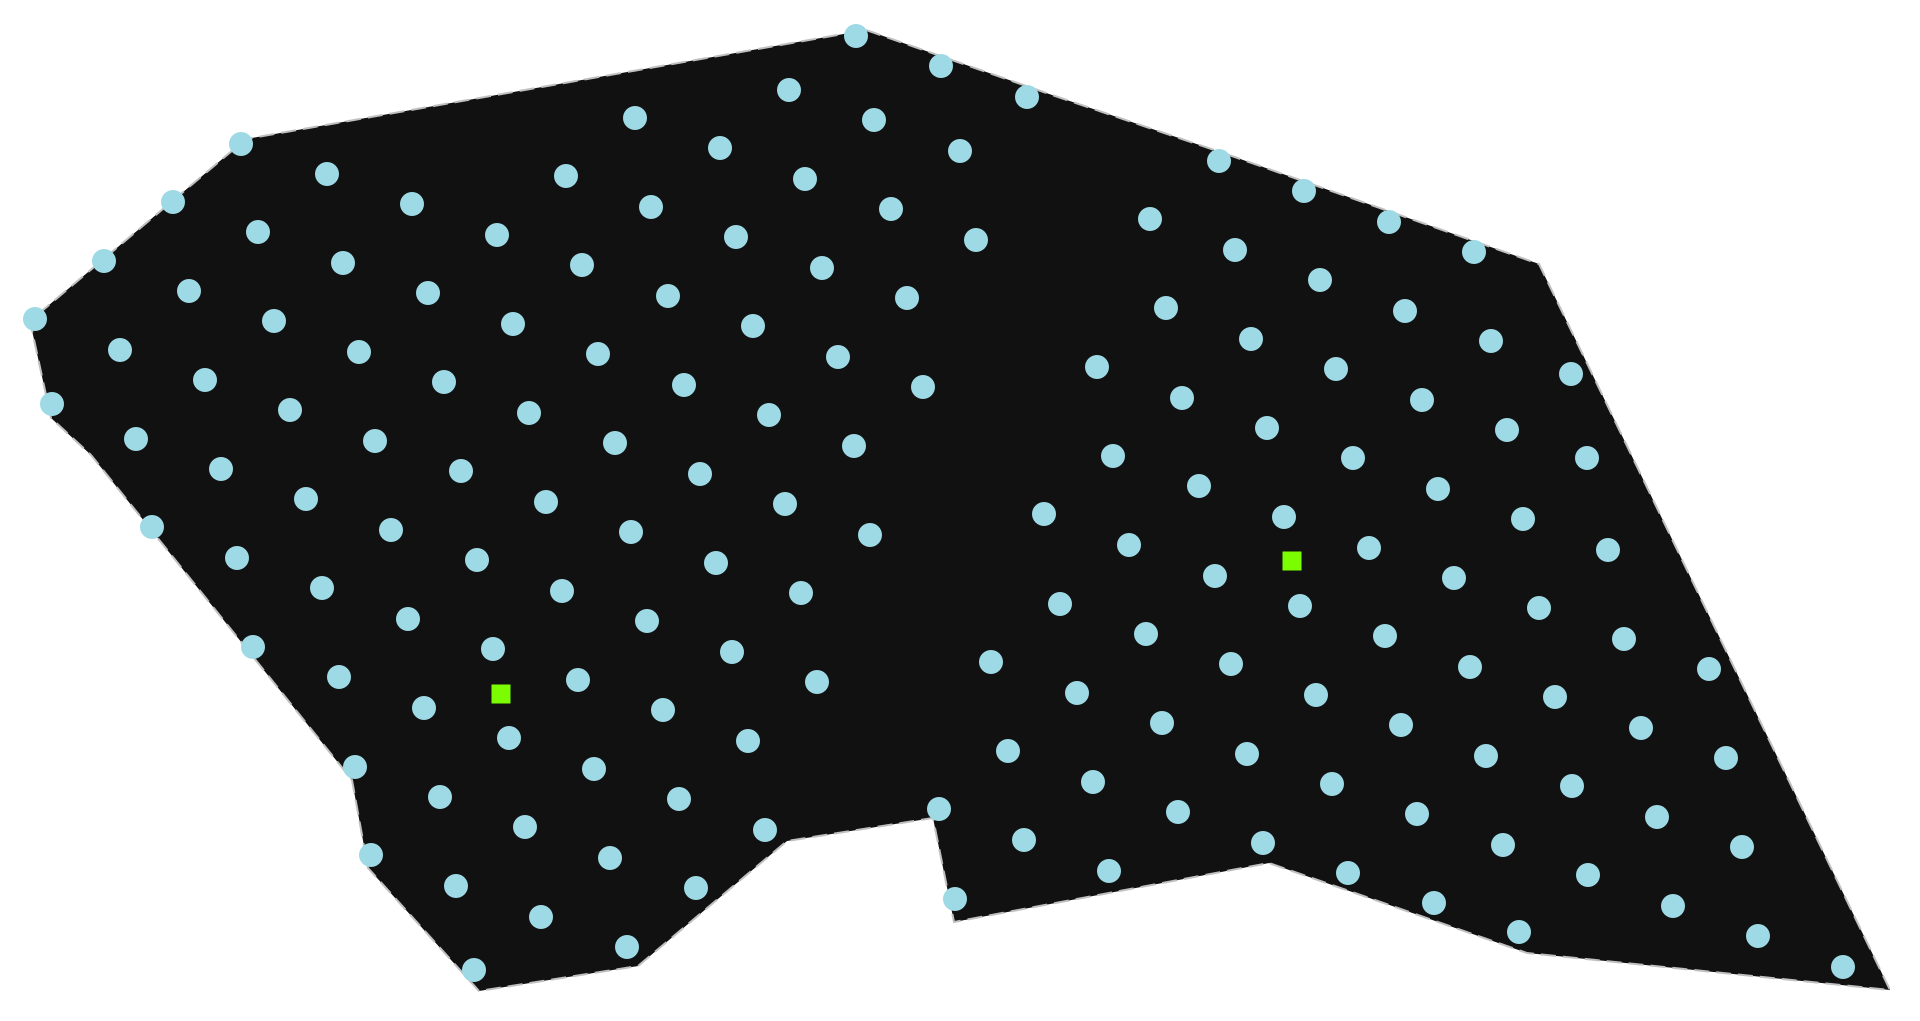

In [4]:
svgplot(L)

### Optimize Gwynt y Mor

In [5]:
P, A = make_planar_embedding(L)

Initial heuristic solution to warm-start the solver:

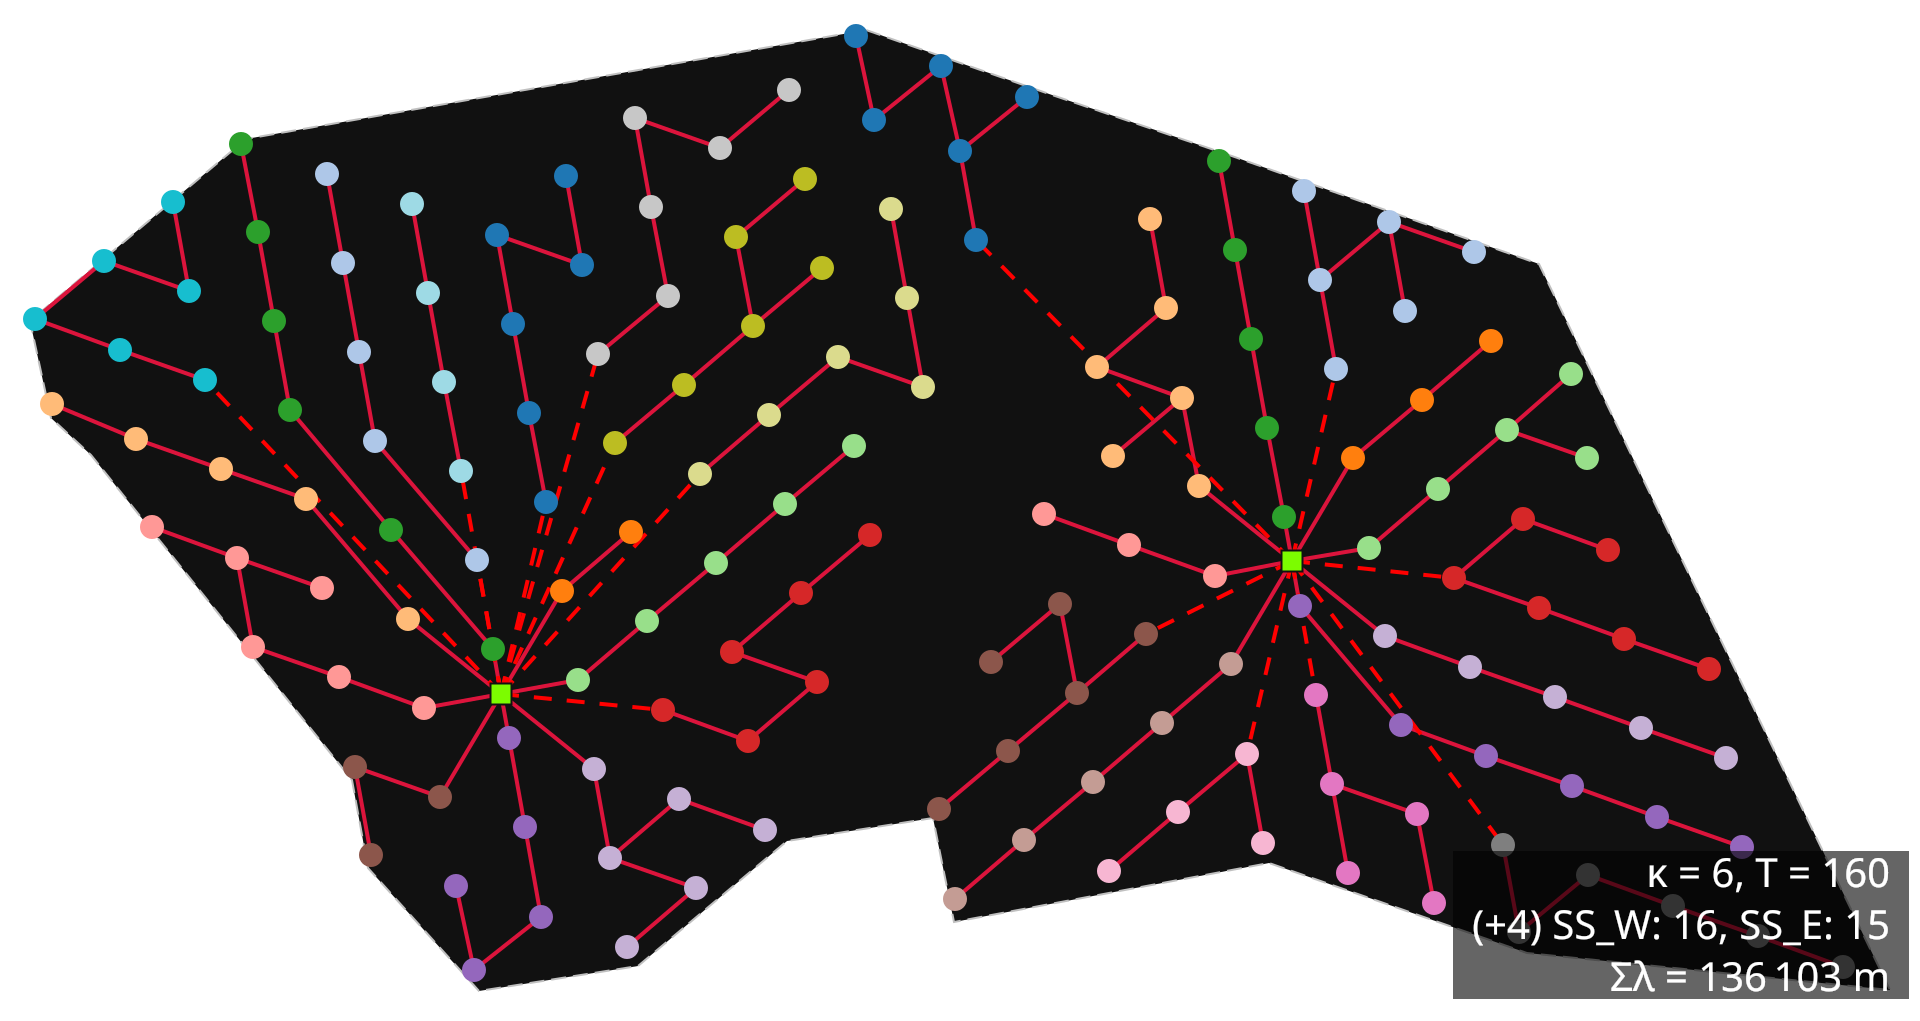

In [6]:
Sʹ = constructor(A, capacity=capacity)
Gʹ = G_from_S(Sʹ, A)
svgplot(Gʹ)

In [7]:
solver = solver_factory('gurobi')

In [8]:
solver.set_problem(
    P,
    A,
    capacity=Sʹ.graph['capacity'],
    model_options=ModelOptions(
        topology='branched',
        feeder_route='segmented',
        feeder_limit='unlimited',
    ),
    warmstart=Sʹ,
)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk


In [9]:
solver.solve(
    mip_gap=0.005,
    time_limit=90,
    verbose=True,
)

Set parameter TimeLimit to value 90
Set parameter MIPGap to value 0.005
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Debian GNU/Linux forky/sid")

CPU model: 11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  90
MIPGap  0.005
MIPFocus  1

Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Optimize a model with 5938 rows, 3976 columns and 22544 nonzeros (Min)
Model fingerprint: 0xdcd2caff
Model has 1988 linear objective coefficients
Variable types: 1988 continuous, 1988 integer (1988 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [4e+02, 1e+04]
  Bounds range     [1e+00, 6e+00]
  RHS range        [1e+00, 2e+02]

Loaded user MIP start with objective 136103

Presolve removed 757 rows and 0 columns
Presolve time: 0.03s
Presolved: 5181 rows, 3976 columns, 190

SolutionInfo(runtime=90.05565905570984, bound=126643.60053630959, objective=129812.84363683013, relgap=0.024413940960934077, termination='maxTimeLimit')

OptiWindNet uses pyomo's `gurobi_persistent` interface with `manage_env=True`, so:

- the Gurobi license is held only between [set_problem()](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.Solver.set_problem) and [get_solution()](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.Solver.get_solution), then released
- options that must be set at Gurobi environment creation (such as `threadlimit`) can be passed by assigning them to [solver.options](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.Solver.options) _before_ calling [set_problem()](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.Solver.set_problem)

Example:

```python
solver.options.update(threadlimit=8)
solver.set_problem(...)
solver.solve(...)
```

In [10]:
S, G = solver.get_solution()

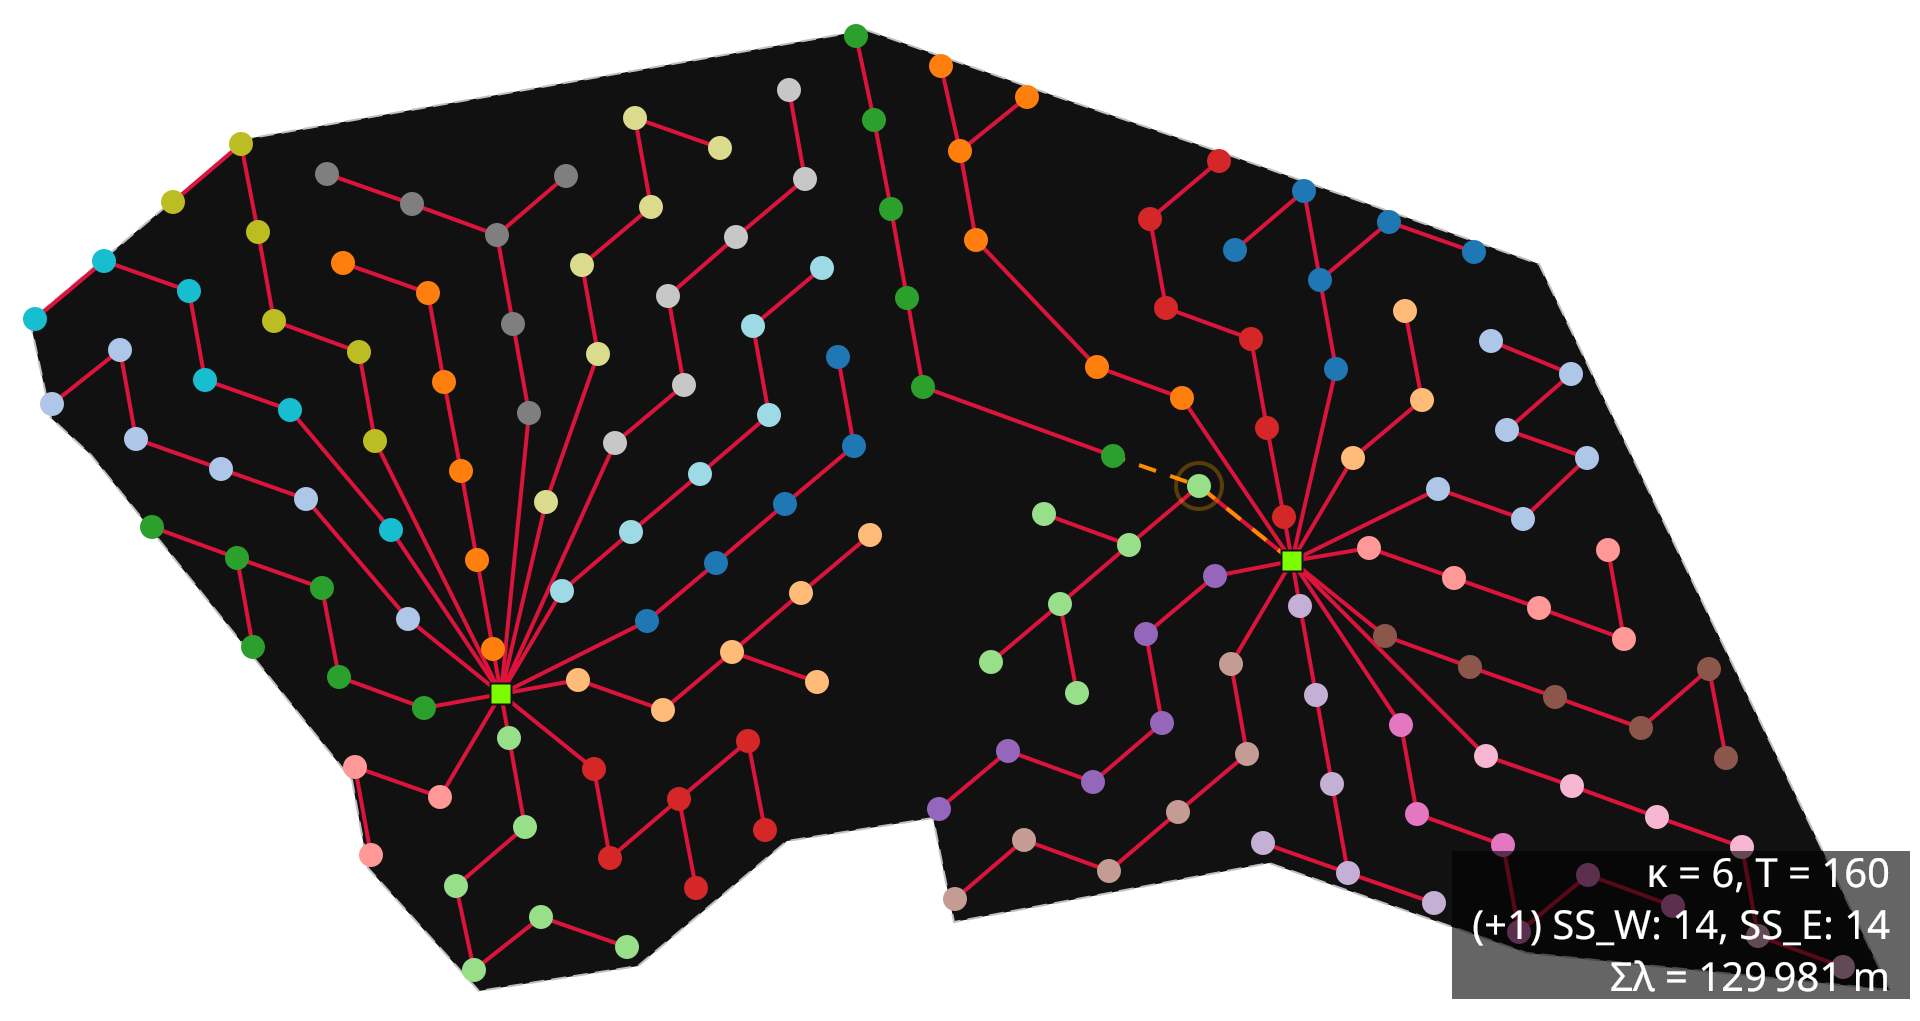

In [11]:
svgplot(G)